[*] 系統共抓取到 19 組檔案，準備處理...

[*] 處理完畢！從 19 張圖片中，成功提取了 19 個花瓣輪廓。
[*] GPA 在第 4 次迭代收斂。


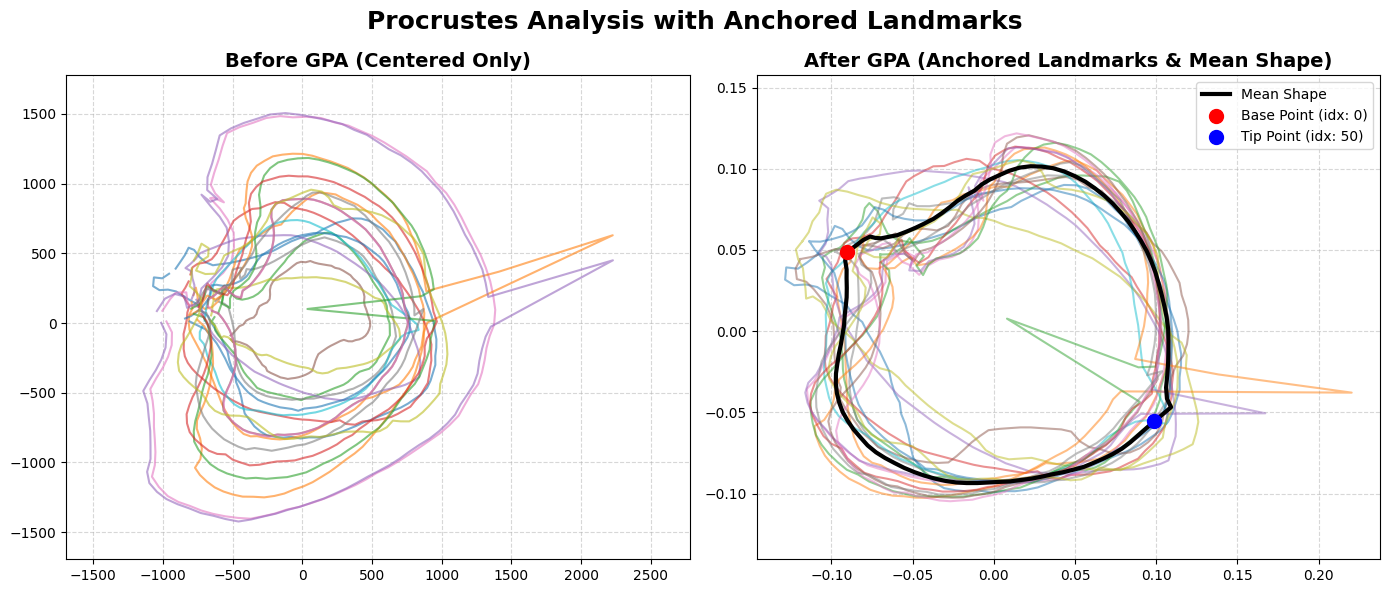


[*] 開始進行主成分分析 (PCA)...


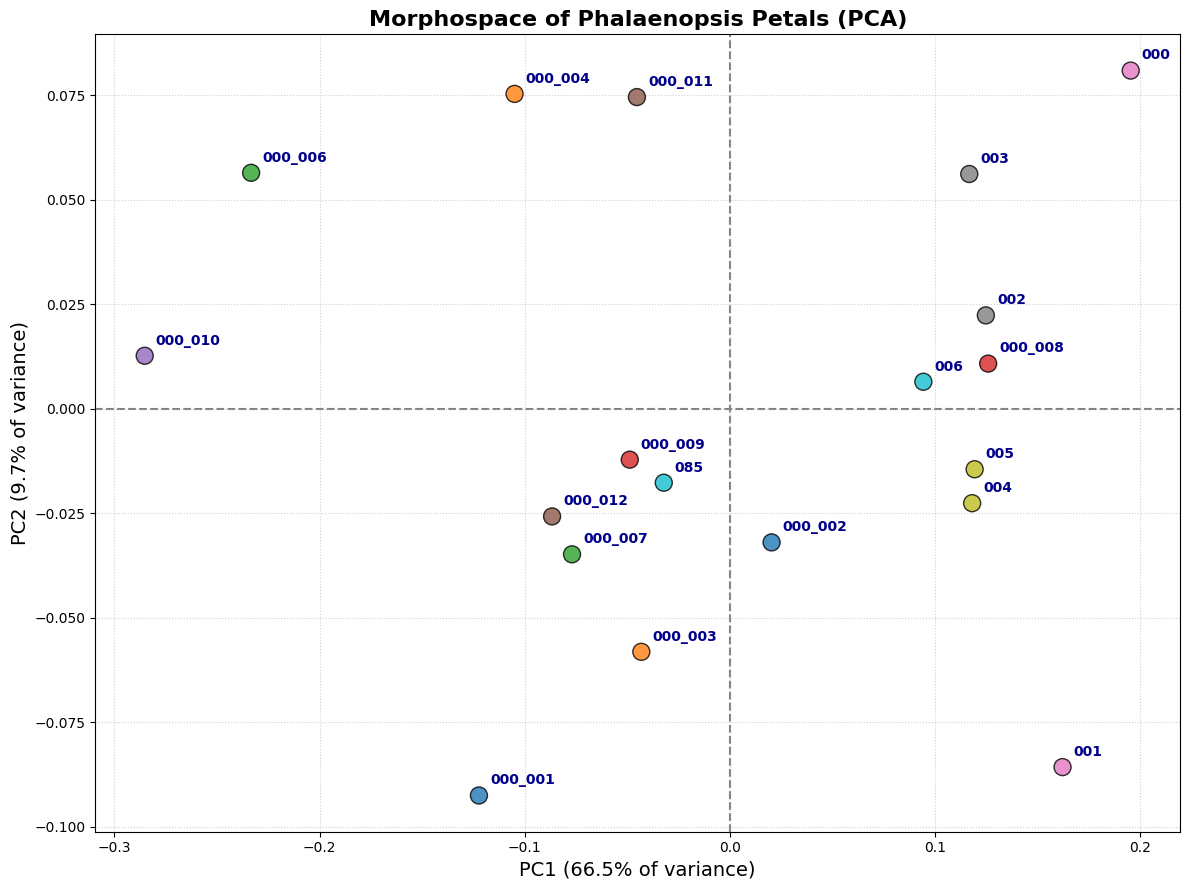

[*] PCA 完成！PC1 解釋了 66.5% 的變異，PC2 解釋了 9.7%。


In [20]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as interp
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA
import os
import glob

# ==========================================
# 1. 定義 GPA 函數 (維持不變)
# ==========================================
def perform_gpa(shapes, max_iter=10, tol=1e-5):
    N, num_points, dims = shapes.shape
    centers = np.mean(shapes, axis=1, keepdims=True)
    centered_shapes = shapes - centers
    centroid_sizes = np.linalg.norm(centered_shapes, axis=(1, 2), keepdims=True)
    scaled_shapes = centered_shapes / centroid_sizes
    
    aligned_shapes = np.copy(scaled_shapes)
    mean_shape = aligned_shapes[0] 
    
    for iteration in range(max_iter):
        for i in range(N):
            R, _ = orthogonal_procrustes(aligned_shapes[i], mean_shape)
            aligned_shapes[i] = np.dot(aligned_shapes[i], R)
            
        new_mean_shape = np.mean(aligned_shapes, axis=0)
        new_mean_shape /= np.linalg.norm(new_mean_shape)
        
        diff = np.linalg.norm(new_mean_shape - mean_shape)
        mean_shape = new_mean_shape
        if diff < tol:
            print(f"[*] GPA 在第 {iteration+1} 次迭代收斂。")
            break
    return aligned_shapes, mean_shape

# ==========================================
# 2. 設定資料夾路徑與參數
# ==========================================
image_dir = './raw_images_0302_labeled_7/the7images/'
mask_dir = './raw_images_0302_labeled_7/the7masks/'

target_class_id = 7 
base_class_id = 1   
num_landmarks = 100 
# 🌟 已移除 exclude_ratio，改用雙錨點 (Base & Tip) 策略

all_petals_landmarks = []
valid_filenames = []

# ==========================================
# 3. 批次處理影像 (🌟 錨定半特徵點策略 🌟)
# ==========================================
image_paths = sorted(glob.glob(os.path.join(image_dir, '*_image.png')))

if not image_paths:
    print(f"[警告] 在 {image_dir} 中找不到任何影像。")
else:
    print(f"[*] 系統共抓取到 {len(image_paths)} 組檔案，準備處理...")

for img_path in image_paths:
    filename = os.path.basename(img_path)
    mask_filename = filename.replace('_image.png', '_mask.png')
    mask_path = os.path.join(mask_dir, mask_filename)
    display_name = filename.replace('_image.png', '') 
    
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        print(f"    - [跳過] 找不到對應的 Mask: {mask_filename}")
        continue

    mask_c1 = np.where(mask == base_class_id, 255, 0).astype(np.uint8)
    cnts_c1, _ = cv2.findContours(mask_c1, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    c1_points = np.vstack(cnts_c1) if cnts_c1 else None

    mask_c7 = np.where(mask == target_class_id, 255, 0).astype(np.uint8)
    kernel = np.ones((5, 5), np.uint8)
    mask_c7 = cv2.morphologyEx(mask_c7, cv2.MORPH_OPEN, kernel)
    cnts_c7, _ = cv2.findContours(mask_c7, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    petal_counter = 1 
    
    for cnt in cnts_c7:
        if cv2.contourArea(cnt) < 100: continue
        N_pts = len(cnt)
        if N_pts < 20: continue 

        # --- 步驟 A: 尋找基部(最近點)與尖端(最遠點) ---
        min_dist = float('inf')
        max_dist = 0
        base_idx = 0
        tip_idx = 0

        if c1_points is not None:
            for idx, pt in enumerate(cnt):
                diff = c1_points[:, 0, :] - pt[0]
                sq_dists = np.sum(diff**2, axis=1)
                local_min = np.min(sq_dists)
                
                if local_min < min_dist:
                    min_dist = local_min
                    base_idx = idx
                if local_min > max_dist:
                    max_dist = local_min
                    tip_idx = idx

        if base_idx == tip_idx:
            continue # 無法區分頭尾，跳過此輪廓

        # --- 步驟 B: 依照輪廓順序，將花瓣切分為左右兩半 ---
        if base_idx < tip_idx:
            path1 = cnt[base_idx : tip_idx + 1]
            path2 = np.concatenate((cnt[tip_idx : ], cnt[ : base_idx + 1]))
        else:
            path1 = np.concatenate((cnt[base_idx : ], cnt[ : tip_idx + 1]))
            path2 = cnt[tip_idx : base_idx + 1]

        if len(path1) < 4 or len(path2) < 4:
            continue # 某一半點數太少，無法進行內插

        x1, y1 = path1[:, 0, 0], path1[:, 0, 1]
        x2, y2 = path2[:, 0, 0], path2[:, 0, 1]
        
        # --- 步驟 C: 雙側等距內插與縫合 ---
        try:
            # 兩半各自內插取 51 個點 (起點與終點皆包含)
            tck1, _ = interp.splprep([x1, y1], s=3.0, per=False) 
            new_x1, new_y1 = interp.splev(np.linspace(0, 1, 51), tck1)
            
            tck2, _ = interp.splprep([x2, y2], s=3.0, per=False) 
            new_x2, new_y2 = interp.splev(np.linspace(0, 1, 51), tck2)
            
            # 縫合：去掉各自的最後一個點 (避免重複)，形成完美的 100 點封閉輪廓
            # 此時：index 0 是基部 (Base)，index 50 是尖端 (Tip)
            final_x = np.concatenate((new_x1[:-1], new_x2[:-1]))
            final_y = np.concatenate((new_y1[:-1], new_y2[:-1]))
            
            landmark_coords = np.column_stack((final_x, final_y))
            all_petals_landmarks.append(landmark_coords)
            
            final_label = f"{display_name}_p{petal_counter}" if len(cnts_c7) > 1 else display_name
            valid_filenames.append(final_label)
            petal_counter += 1
            
        except Exception as e:
            print(f"    - [跳過] {filename} 輪廓內插失敗: {e}")

# ==========================================
# 4. 執行 GPA 與 視覺化
# ==========================================
shapes_array = np.array(all_petals_landmarks)
print(f"\n[*] 處理完畢！從 {len(image_paths)} 張圖片中，成功提取了 {len(shapes_array)} 個花瓣輪廓。")

if len(shapes_array) < 2:
    print("提取出的形狀數量不足 2 個，無法進行 GPA 分析。請檢查影像。")
else:
    aligned_shapes, mean_shape = perform_gpa(shapes_array)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].set_title("Before GPA (Centered Only)", fontsize=14, fontweight='bold')
    for i in range(len(shapes_array)):
        center = np.mean(shapes_array[i], axis=0)
        centered = shapes_array[i] - center
        axes[0].plot(centered[:, 0], centered[:, 1], alpha=0.6, linewidth=1.5)
    axes[0].axis('equal')
    axes[0].grid(True, linestyle='--', alpha=0.5)

    axes[1].set_title("After GPA (Anchored Landmarks & Mean Shape)", fontsize=14, fontweight='bold')
    for i in range(len(aligned_shapes)):
        # 將輪廓閉合繪製 (把第一個點連回最後一個點)
        closed_x = np.append(aligned_shapes[i, :, 0], aligned_shapes[i, 0, 0])
        closed_y = np.append(aligned_shapes[i, :, 1], aligned_shapes[i, 0, 1])
        axes[1].plot(closed_x, closed_y, alpha=0.5, linewidth=1.5)
    
    # 畫出黑色的平均形狀
    mean_closed_x = np.append(mean_shape[:, 0], mean_shape[0, 0])
    mean_closed_y = np.append(mean_shape[:, 1], mean_shape[0, 1])
    axes[1].plot(mean_closed_x, mean_closed_y, color='black', linewidth=3, label='Mean Shape')
    
    # 🌟 精準標示錨點：第 0 點為基部，第 50 點為尖端 🌟
    axes[1].scatter(mean_shape[0, 0], mean_shape[0, 1], color='red', s=100, label='Base Point (idx: 0)', zorder=5)
    axes[1].scatter(mean_shape[50, 0], mean_shape[50, 1], color='blue', s=100, label='Tip Point (idx: 50)', zorder=5)

    axes[1].axis('equal')
    axes[1].grid(True, linestyle='--', alpha=0.5)
    axes[1].legend()

    plt.suptitle("Procrustes Analysis with Anchored Landmarks", fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ==========================================
# 5. 執行主成分分析 (PCA) 與繪製形態空間
# ==========================================
    print("\n[*] 開始進行主成分分析 (PCA)...")
    N, num_points, dims = aligned_shapes.shape
    flattened_shapes = aligned_shapes.reshape(N, -1)

    pca = PCA(n_components=2)
    pcs = pca.fit_transform(flattened_shapes)
    explained_variance = pca.explained_variance_ratio_ * 100

    fig_pca, ax_pca = plt.subplots(figsize=(12, 9)) 
    scatter = ax_pca.scatter(pcs[:, 0], pcs[:, 1], c=range(N), cmap='tab10', s=150, alpha=0.8, edgecolors='k', zorder=3)

    for i in range(N):
        actual_name = valid_filenames[i]
        ax_pca.annotate(actual_name, (pcs[i, 0], pcs[i, 1]),
                    xytext=(8, 8), textcoords='offset points', 
                    fontsize=10, fontweight='bold', color='darkblue')

    ax_pca.set_title("Morphospace of Phalaenopsis Petals (PCA)", fontsize=16, fontweight='bold')
    ax_pca.set_xlabel(f"PC1 ({explained_variance[0]:.1f}% of variance)", fontsize=14)
    ax_pca.set_ylabel(f"PC2 ({explained_variance[1]:.1f}% of variance)", fontsize=14)

    ax_pca.axhline(0, color='gray', linestyle='--', linewidth=1.5, zorder=1)
    ax_pca.axvline(0, color='gray', linestyle='--', linewidth=1.5, zorder=1)
    ax_pca.grid(True, linestyle=':', alpha=0.6, zorder=0)

    plt.tight_layout()
    plt.show()
    
    print(f"[*] PCA 完成！PC1 解釋了 {explained_variance[0]:.1f}% 的變異，PC2 解釋了 {explained_variance[1]:.1f}%。")


[*] 正在重建 PC1 與 PC2 的極端形狀 (Shape Reconstruction)...


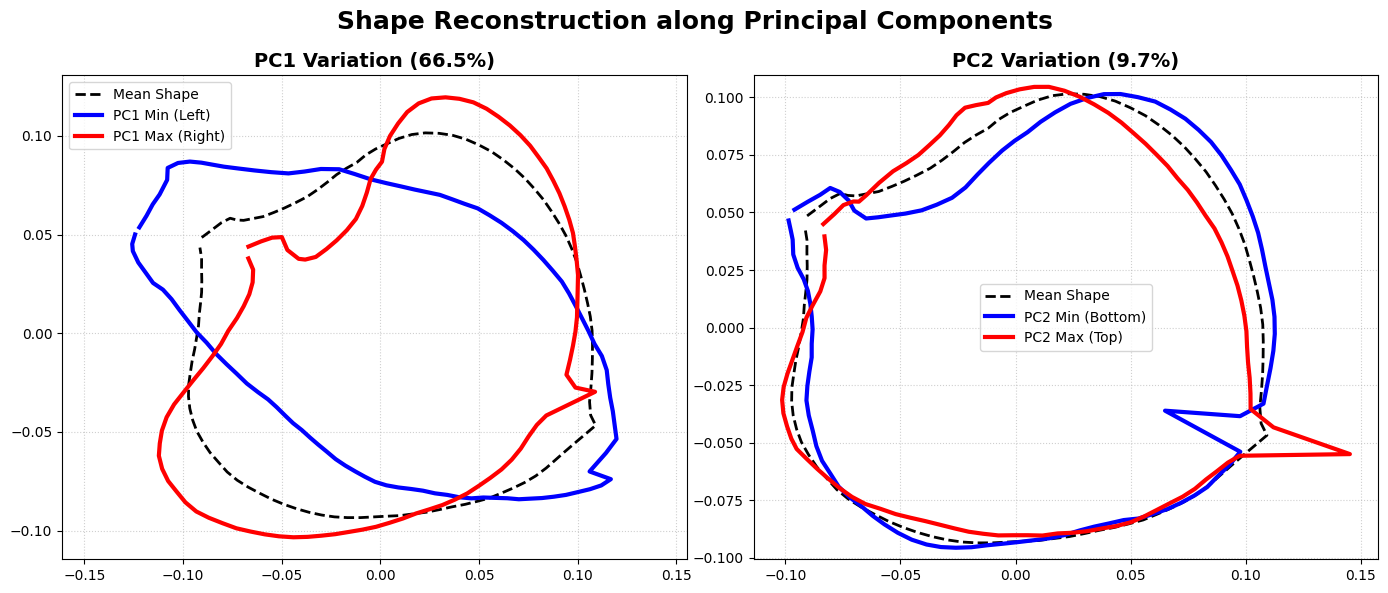

In [21]:
# ==========================================
# 6. 視覺化主成分 (PC1 & PC2) 的極端形狀
# ==========================================
print("\n[*] 正在重建 PC1 與 PC2 的極端形狀 (Shape Reconstruction)...")

# 步驟 A: 找出 PC1 與 PC2 在你資料集中的實際最大值與最小值
pc1_min, pc1_max = np.min(pcs[:, 0]), np.max(pcs[:, 0])
pc2_min, pc2_max = np.min(pcs[:, 1]), np.max(pcs[:, 1])

# 步驟 B: 在形態空間中創造 4 個代表「極端極限」的虛擬點
# 注意：我們降維時設定了 n_components=2，所以這裡只要給 [PC1, PC2] 的座標
synthetic_pcs = np.array([
    [pc1_min, 0],  # 代表 PC1 最小值的虛擬花瓣 (PC2 固定為平均值 0)
    [pc1_max, 0],  # 代表 PC1 最大值的虛擬花瓣
    [0, pc2_min],  # 代表 PC2 最小值的虛擬花瓣 (PC1 固定為平均值 0)
    [0, pc2_max]   # 代表 PC2 最大值的虛擬花瓣
])

# 步驟 C: 將這 4 個虛擬點「逆轉換」回原始的形狀空間 (Flattened 狀態)
reconstructed_flattened = pca.inverse_transform(synthetic_pcs)

# 將攤平的陣列重新塑型回 (4, 100, 2) 的座標格式
reconstructed_shapes = reconstructed_flattened.reshape(4, num_points, dims)

# 步驟 D: 繪製對比圖
fig_ext, axes_ext = plt.subplots(1, 2, figsize=(14, 6))

# --- 左圖：PC1 的形狀變異 ---
axes_ext[0].set_title(f"PC1 Variation ({explained_variance[0]:.1f}%)", fontsize=14, fontweight='bold')
# 畫出平均形狀當作參考基準 (黑色虛線)
axes_ext[0].plot(mean_shape[:, 0], mean_shape[:, 1], color='black', linestyle='--', linewidth=2, label='Mean Shape')
# 畫出 PC1 最小與最大的極端形狀
axes_ext[0].plot(reconstructed_shapes[0, :, 0], reconstructed_shapes[0, :, 1], color='blue', linewidth=3, label='PC1 Min (Left)')
axes_ext[0].plot(reconstructed_shapes[1, :, 0], reconstructed_shapes[1, :, 1], color='red', linewidth=3, label='PC1 Max (Right)')
axes_ext[0].axis('equal')
axes_ext[0].grid(True, linestyle=':', alpha=0.6)
axes_ext[0].legend()

# --- 右圖：PC2 的形狀變異 ---
axes_ext[1].set_title(f"PC2 Variation ({explained_variance[1]:.1f}%)", fontsize=14, fontweight='bold')
# 畫出平均形狀當作參考基準 (黑色虛線)
axes_ext[1].plot(mean_shape[:, 0], mean_shape[:, 1], color='black', linestyle='--', linewidth=2, label='Mean Shape')
# 畫出 PC2 最小與最大的極端形狀
axes_ext[1].plot(reconstructed_shapes[2, :, 0], reconstructed_shapes[2, :, 1], color='blue', linewidth=3, label='PC2 Min (Bottom)')
axes_ext[1].plot(reconstructed_shapes[3, :, 0], reconstructed_shapes[3, :, 1], color='red', linewidth=3, label='PC2 Max (Top)')
axes_ext[1].axis('equal')
axes_ext[1].grid(True, linestyle=':', alpha=0.6)
axes_ext[1].legend()

plt.suptitle("Shape Reconstruction along Principal Components", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()


[*] 正在計算並繪製 PC1~PC8 的變異解釋佔比...


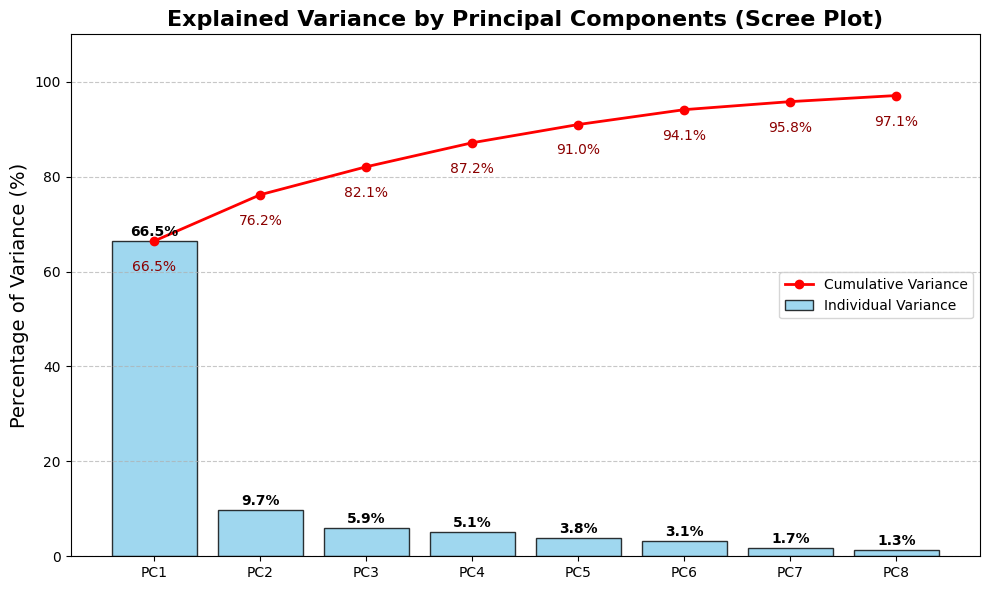

In [22]:
# ==========================================
# 7. 繪製主成分解釋變異佔比直方圖 (Scree Plot)
# ==========================================
print("\n[*] 正在計算並繪製 PC1~PC8 的變異解釋佔比...")

# 確保我們最多取 8 個成分 (注意：如果成功提取的花瓣樣本數 N 小於 9，
# PCA 的極限成分數會是 N-1，這裡做個保護機制)
max_components = min(8, N - 1)

# 重新建立一個提取更多成分的 PCA 模型
pca_multi = PCA(n_components=max_components)
pca_multi.fit(flattened_shapes)

# 取得各個 PC 的解釋變異百分比，以及計算「累積百分比」
explained_var = pca_multi.explained_variance_ratio_ * 100
cumulative_var = np.cumsum(explained_var)

x_labels = [f"PC{i+1}" for i in range(max_components)]

fig_var, ax_var = plt.subplots(figsize=(10, 6))

# 1. 畫出每個 PC 的個別佔比 (藍色直方圖/長條圖)
bars = ax_var.bar(x_labels, explained_var, color='skyblue', edgecolor='black', alpha=0.8, label='Individual Variance')

# 在長條圖上方標註具體數值
for bar in bars:
    yval = bar.get_height()
    ax_var.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.1f}%", 
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
# 2. 畫出「累積變異」佔比 (紅色折線圖)
ax_var.plot(x_labels, cumulative_var, color='red', marker='o', linewidth=2, label='Cumulative Variance')

# 在折線圖節點標註累積數值
for i, val in enumerate(cumulative_var):
    ax_var.text(i, val - 4, f"{val:.1f}%", ha='center', va='top', color='darkred', fontsize=10)
    
# 設定圖表外觀
ax_var.set_title("Explained Variance by Principal Components (Scree Plot)", fontsize=16, fontweight='bold')
ax_var.set_ylabel("Percentage of Variance (%)", fontsize=14)
ax_var.set_ylim(0, 110) # Y 軸最高設為 110 留點空間顯示文字
ax_var.grid(axis='y', linestyle='--', alpha=0.7)
ax_var.legend(loc='center right')

plt.tight_layout()
plt.show()

In [23]:
!ls './raw_images_0302_labeled_7/the7images/'

000_001_image.png  000_007_image.png  000_image.png  006_image.png
000_002_image.png  000_008_image.png  001_image.png  085_image.png
000_003_image.png  000_009_image.png  002_image.png  @eaDir
000_004_image.png  000_010_image.png  003_image.png  Thumbs.db
000_005_bad.png    000_011_image.png  004_image.png
000_006_image.png  000_012_image.png  005_image.png


# 計算花瓣長寬比


                 🌿 蘭花生物學形態特徵報告 (長度、寬度、長寬比)                  
【量化策略與取點原理 (Methodology)】
 📏 真實長度 (True Length) 取點：
    基於植物解剖學，以「柱頭中心」為生長原點。在花瓣輪廓上，
    尋找距離柱頭【最近的點】定義為「基部 (Base)」，【最遠的點】
    定義為「尖端 (Tip)」。兩點的直線連線即為真實生長中軸。

 📐 垂直寬度 (Perpendicular Width) 取點：
    為排除花瓣自然彎曲或拍照角度造成的誤差，寬度必須與生長中軸
    【絕對垂直】。利用向量內積 (Dot Product)，將輪廓上所有點
    投影至中軸的「法向量」上，找出左右兩側投影距離最遠的極值點，
    其總跨距即為不受形變干擾的最大垂直寬度。
----------------------------------------------------------------------
指標 (Metrics)              | 左花瓣 (Petal_L)   | 右花瓣 (Petal_R)  
----------------------------------------------------------------------
中心輻射長度 (距柱頭 px)        | 1424.8          | 1432.7         
花瓣真實長度 (L, px)         | 1249.2          | 1282.7         
花瓣垂直寬度 (W, px)         | 1222.2          | 1216.3         
長寬比例 (Aspect Ratio)    | 1.022           | 1.055          
----------------------------------------------------------------------
⚖️ 長度對稱性：左右誤差率為 2.61%
⚖️ 寬度對稱性：左右誤差率為 0.48%



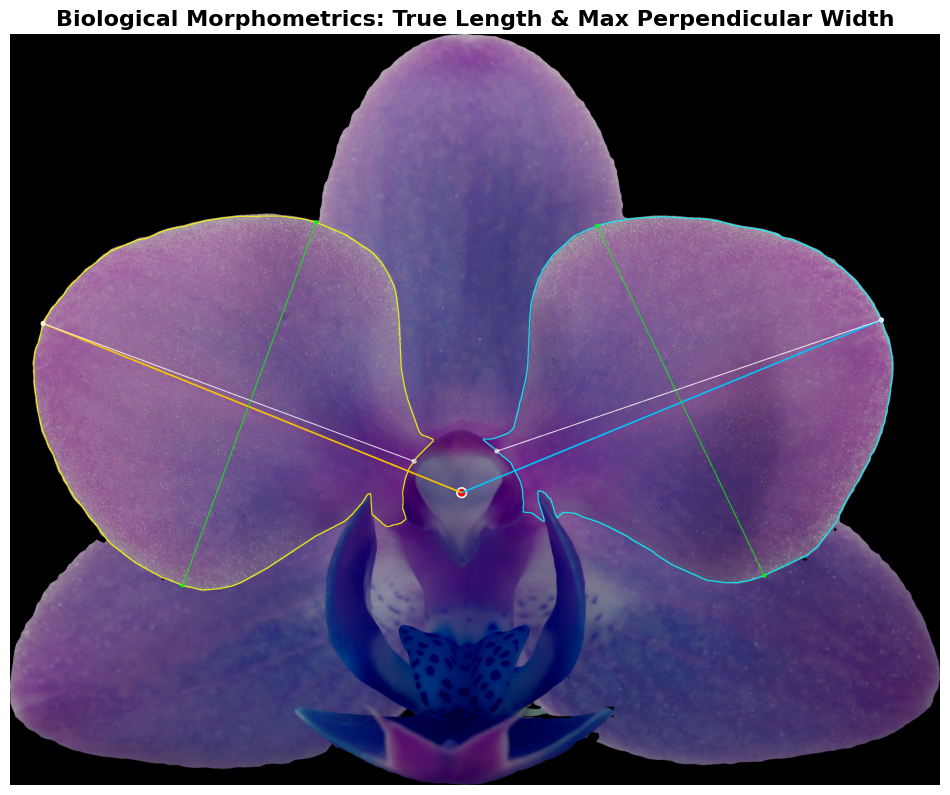

In [24]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import math

# ==========================================
# 定義生物學中軸與寬度、凸包(Solidity)分析函式
# ==========================================
def get_traditional_metrics(binary_mask, origin_point):
    kernel = np.ones((5, 5), np.uint8)
    clean_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)
    contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours: return None
    cnt = max(contours, key=cv2.contourArea)
    
    # 🌟 新增：計算面積與凸包 (Solidity) 🌟
    area = cv2.contourArea(cnt)
    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)
    solidity = area / hull_area if hull_area > 0 else 0
    
    max_dist, min_dist = 0, float('inf')
    farthest_point, closest_point = None, None
    
    for pt in cnt:
        p = pt[0]
        dist = np.linalg.norm(p - origin_point)
        if dist > max_dist: max_dist, farthest_point = dist, tuple(p)
        if dist < min_dist: min_dist, closest_point = dist, tuple(p)
            
    base_np = np.array(closest_point, dtype=float)
    tip_np = np.array(farthest_point, dtype=float)
    axis_vector = tip_np - base_np
    true_length = np.linalg.norm(axis_vector)
    
    true_width, aspect_ratio = 0, 0
    if true_length > 0:
        unit_axis = axis_vector / true_length
        perp_vector = np.array([-unit_axis[1], unit_axis[0]])
        
        max_pos_proj, max_neg_proj = 0, 0
        for pt in cnt:
            proj_dist = np.dot(np.array(pt[0], dtype=float) - base_np, perp_vector)
            if proj_dist > max_pos_proj: max_pos_proj = proj_dist
            elif proj_dist < max_neg_proj: max_neg_proj = proj_dist
                
        true_width = max_pos_proj - max_neg_proj 
        aspect_ratio = true_length / true_width if true_width > 0 else 0

    return {
        "length": true_length, 
        "width": true_width, 
        "aspect_ratio": aspect_ratio,
        "solidity": solidity  # 🌟 輸出 Solidity
    }

# ==========================================
# 1. 讀取影像與遮罩 (請確認路徑)
# ==========================================
image_path = './raw_images_0302_labeled_7/the7images/000_009_image.png' 
mask_path = './raw_images_0302_labeled_7/the7masks/000_009_mask.png'   

img_rgba = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
channels = img_rgba.shape[2] if len(img_rgba.shape) == 3 else 1
if channels == 3:
    img_rgba = cv2.cvtColor(img_rgba, cv2.COLOR_BGR2RGBA)
elif channels == 1:
    img_rgba = cv2.cvtColor(img_rgba, cv2.COLOR_GRAY2RGBA)

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
img_rgb_content = cv2.cvtColor(img_rgba, cv2.COLOR_BGRA2RGB)

# ==========================================
# 2. 計算 Class 1 (柱頭) 的幾何中心點
# ==========================================
mask_c1 = np.where(mask == 1, 255, 0).astype(np.uint8)
M_c1 = cv2.moments(mask_c1)
if M_c1["m00"] != 0:
    column_cX = int(M_c1["m10"] / M_c1["m00"])
    column_cY = int(M_c1["m01"] / M_c1["m00"])
    column_centroid = np.array([column_cX, column_cY])
else:
    raise ValueError("找不到 Class 1 (柱頭) 的像素，無法建立生長中軸！")

# ==========================================
# 3. 定義「生物學中軸與寬度」分析函式
# ==========================================
def analyze_biological_axis(binary_mask, origin_point):
    """計算從起源點(柱頭)出發的花瓣中軸線、真實長度與垂直寬度"""
    kernel = np.ones((5, 5), np.uint8)
    clean_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)
    
    contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    
    cnt = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    
    # 尋找距離柱頭「最遠」與「最近」的點
    max_dist = 0
    farthest_point = None
    min_dist = float('inf')
    closest_point = None
    
    for pt in cnt:
        p = pt[0]
        dist = np.linalg.norm(p - origin_point)
        if dist > max_dist:
            max_dist = dist
            farthest_point = tuple(p)
        if dist < min_dist:
            min_dist = dist
            closest_point = tuple(p)
            
    # 真實花瓣長度：尖端到基部的直線距離
    base_np = np.array(closest_point, dtype=float)
    tip_np = np.array(farthest_point, dtype=float)
    axis_vector = tip_np - base_np
    true_length = np.linalg.norm(axis_vector)
    
    # 🌟 新增：計算與生長軸垂直的最大寬度 🌟
    true_width = 0
    width_pt1 = closest_point
    width_pt2 = closest_point
    aspect_ratio = 0
    
    if true_length > 0:
        # 1. 取得生長軸的單位向量
        unit_axis = axis_vector / true_length
        # 2. 取得垂直於生長軸的法向量 (逆時針轉 90 度)
        perp_vector = np.array([-unit_axis[1], unit_axis[0]])
        
        max_pos_proj = 0
        max_neg_proj = 0
        pt_pos = base_np
        pt_neg = base_np
        
        # 3. 將所有輪廓點投影到法向量上，找出距離軸心最遠的左右兩點
        for pt in cnt:
            p = np.array(pt[0], dtype=float)
            vec_from_base = p - base_np
            # 內積計算投影距離
            proj_dist = np.dot(vec_from_base, perp_vector)
            
            if proj_dist > max_pos_proj:
                max_pos_proj = proj_dist
                pt_pos = p
            elif proj_dist < max_neg_proj:
                max_neg_proj = proj_dist
                pt_neg = p
                
        # 寬度為正向最大投影距離 + 負向最大投影距離的絕對值
        true_width = max_pos_proj - max_neg_proj 
        width_pt1 = tuple(pt_pos.astype(int))
        width_pt2 = tuple(pt_neg.astype(int))
        aspect_ratio = true_length / true_width if true_width > 0 else 0

    return {
        "contour": cnt,
        "area": area,
        "tip_point": farthest_point,
        "base_point": closest_point,
        "width_pt1": width_pt1,      # 🌟 寬度極值點 1
        "width_pt2": width_pt2,      # 🌟 寬度極值點 2
        "axis_length_from_column": max_dist, 
        "true_petal_length": true_length,    
        "true_petal_width": true_width,      # 🌟 真實寬度
        "aspect_ratio": aspect_ratio         # 🌟 長寬比
    }

# ==========================================
# 4. 執行分析：Petal_L (ID:6) vs Petal_R (ID:7)
# ==========================================
mask_L = np.where(mask == 6, 255, 0).astype(np.uint8)
mask_R = np.where(mask == 7, 255, 0).astype(np.uint8)

data_L = analyze_biological_axis(mask_L, column_centroid)
data_R = analyze_biological_axis(mask_R, column_centroid)

# ==========================================
# 5. 視覺化：畫出真正的生長中軸線與寬度線
# ==========================================
dark_bg = np.zeros_like(img_rgb_content)
result_img = cv2.addWeighted(img_rgb_content, 0.7, dark_bg, 0.3, 0)

cv2.circle(result_img, tuple(column_centroid), 12, (255, 0, 0), -1)
cv2.circle(result_img, tuple(column_centroid), 15, (255, 255, 255), 3)

def draw_petal_features(img, data, color_contour, color_axis):
    if not data: return
    # 1. 畫輪廓
    cv2.drawContours(img, [data["contour"]], -1, color_contour, 2)
    
    # 2. 標示最遠點 (尖端) 與最近點 (基部)
    cv2.circle(img, data["tip_point"], 8, (255, 255, 255), -1)
    cv2.circle(img, data["base_point"], 8, (200, 200, 200), -1)
    
    # 3. 畫出「柱頭 -> 尖端」的生長中軸線
    cv2.line(img, tuple(column_centroid), data["tip_point"], color_axis, 4)
    
    # 4. 畫出花瓣長度線 (基部 -> 尖端) (細實線)
    cv2.line(img, data["base_point"], data["tip_point"], (255, 255, 255), 2)
    
    # 5. 🌟 畫出垂直寬度線 (亮綠色) 🌟
    cv2.line(img, data["width_pt1"], data["width_pt2"], (0, 255, 0), 2)
    cv2.circle(img, data["width_pt1"], 6, (0, 255, 0), -1)
    cv2.circle(img, data["width_pt2"], 6, (0, 255, 0), -1)

# 畫左花瓣 (黃色系)
draw_petal_features(result_img, data_L, (255, 255, 0), (255, 200, 0))
# 畫右花瓣 (青色系)
draw_petal_features(result_img, data_R, (0, 255, 255), (0, 200, 255))

# ==========================================
# 6. 終端機列印：生物形態學報告
# ==========================================
print("\n" + "="*70)
print(f"{'🌿 蘭花生物學形態特徵報告 (長度、寬度、長寬比)':^60}")
print("="*70)

# 🌟 新增：印出策略與取點原理 🌟
print("【量化策略與取點原理 (Methodology)】")
print(" 📏 真實長度 (True Length) 取點：")
print("    基於植物解剖學，以「柱頭中心」為生長原點。在花瓣輪廓上，")
print("    尋找距離柱頭【最近的點】定義為「基部 (Base)」，【最遠的點】")
print("    定義為「尖端 (Tip)」。兩點的直線連線即為真實生長中軸。")
print("")
print(" 📐 垂直寬度 (Perpendicular Width) 取點：")
print("    為排除花瓣自然彎曲或拍照角度造成的誤差，寬度必須與生長中軸")
print("    【絕對垂直】。利用向量內積 (Dot Product)，將輪廓上所有點")
print("    投影至中軸的「法向量」上，找出左右兩側投影距離最遠的極值點，")
print("    其總跨距即為不受形變干擾的最大垂直寬度。")
print("-" * 70)

# 下方保留原本的數據報表
print(f"{'指標 (Metrics)':<25} | {'左花瓣 (Petal_L)':<15} | {'右花瓣 (Petal_R)':<15}")
print("-" * 70)
if data_L and data_R:
    print(f"{'中心輻射長度 (距柱頭 px)':<22} | {data_L['axis_length_from_column']:<15.1f} | {data_R['axis_length_from_column']:<15.1f}")
    print(f"{'花瓣真實長度 (L, px)':<22} | {data_L['true_petal_length']:<15.1f} | {data_R['true_petal_length']:<15.1f}")
    print(f"{'花瓣垂直寬度 (W, px)':<22} | {data_L['true_petal_width']:<15.1f} | {data_R['true_petal_width']:<15.1f}")
    print(f"{'長寬比例 (Aspect Ratio)':<22} | {data_L['aspect_ratio']:<15.3f} | {data_R['aspect_ratio']:<15.3f}")
    
    length_diff_ratio = (abs(data_L['true_petal_length'] - data_R['true_petal_length']) / max(data_L['true_petal_length'], data_R['true_petal_length'])) * 100
    width_diff_ratio = (abs(data_L['true_petal_width'] - data_R['true_petal_width']) / max(data_L['true_petal_width'], data_R['true_petal_width'])) * 100
    
    print("-" * 70)
    print(f"⚖️ 長度對稱性：左右誤差率為 {length_diff_ratio:.2f}%")
    print(f"⚖️ 寬度對稱性：左右誤差率為 {width_diff_ratio:.2f}%")
print("="*70 + "\n")
# 顯示結果影像
plt.figure(figsize=(12, 12))
plt.imshow(result_img)
plt.title("Biological Morphometrics: True Length & Max Perpendicular Width", fontsize=16, fontweight='bold')
plt.axis('off')
plt.show()

In [25]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np

# 假設這是你收集到的 20 片花瓣的數據陣列 (需確保兩者的樣本順序完全對應！)
# pc1_scores = pcs[:, 0]  # 來自 PCA 的結果
# aspect_ratios = [...]   # 來自你剛剛算出來的 aspect_ratio 清單

print("\n[*] 正在進行相關性分析：傳統長寬比 vs 幾何形態特徵 (PC1)...")

# 1. 進行線性迴歸分析
slope, intercept, r_value, p_value, std_err = stats.linregress(aspect_ratios, pc1_scores)
r_squared = r_value ** 2

# 2. 繪製散佈圖與趨勢線
fig_corr, ax_corr = plt.subplots(figsize=(8, 6))

# 畫出散佈點 (以綠色表示)
ax_corr.scatter(aspect_ratios, pc1_scores, color='seagreen', s=100, alpha=0.8, edgecolors='k', zorder=3)

# 畫出迴歸趨勢線
trendline_x = np.linspace(min(aspect_ratios), max(aspect_ratios), 100)
trendline_y = slope * trendline_x + intercept
ax_corr.plot(trendline_x, trendline_y, color='red', linestyle='--', linewidth=2, zorder=2)

# 3. 圖表美化與標註
ax_corr.set_title("Correlation: Aspect Ratio vs. PC1 Score", fontsize=16, fontweight='bold')
ax_corr.set_xlabel("Traditional Aspect Ratio (Length / Max Width)", fontsize=14)
ax_corr.set_ylabel("PC1 Score (Geometric Shape Variation)", fontsize=14)

# 將統計結果 (R平方與 p-value) 印在圖表上
stats_text = f"Pearson r = {r_value:.3f}\nR² = {r_squared:.3f}\np-value = {p_value:.4e}"
ax_corr.text(0.05, 0.95, stats_text, transform=ax_corr.transAxes, fontsize=12,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

ax_corr.grid(True, linestyle=':', alpha=0.6, zorder=0)
plt.tight_layout()
plt.show()

# 4. 終端機列印結論
if p_value < 0.05:
    print(f"[*] 結論：長寬比與 PC1 呈現【顯著相關】(p < 0.05, R² = {r_squared:.2f})。")
    print("    -> 幾何形態學的 PC1 軸，在數學上確實高度反映了花瓣長寬比例的變化！")
else:
    print(f"[*] 結論：長寬比與 PC1 【無顯著相關】(p >= 0.05)。")
    print("    -> PC1 可能代表著更複雜的形狀特徵 (例如邊緣彎曲度、不對稱性)，而非單純的長寬比。")


[*] 正在進行相關性分析：傳統長寬比 vs 幾何形態特徵 (PC1)...


NameError: name 'aspect_ratios' is not defined